In [1]:
%pip install pandas numpy scikit-learn matplotlib xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [3]:
train_data=pd.read_csv("kepler_train_by_host.xls");
test_data=pd.read_csv("kepler_test_by_host.xls");
print(train_data.shape);
print(test_data.shape);

(7662, 60)
(1902, 60)


In [4]:
print("Training target Distribution:")
print(train_data["koi_disposition"].value_counts())
print("\nTesting target Distribution:")
print(test_data["koi_disposition"].value_counts())


Training target Distribution:
koi_disposition
FALSE POSITIVE    4002
CONFIRMED         1850
CANDIDATE         1810
Name: count, dtype: int64

Testing target Distribution:
koi_disposition
FALSE POSITIVE    1021
CONFIRMED          443
CANDIDATE          438
Name: count, dtype: int64


In [5]:
train_labeled=train_data[train_data["koi_disposition"].isin(["CONFIRMED","FALSE POSITIVE"])].copy()
test_labeled=test_data[test_data["koi_disposition"].isin(["CONFIRMED","FALSE POSITIVE"])].copy()
candidate_data=test_data[test_data["koi_disposition"]=="CANDIDATE"].copy()
print("Known training objects",len(train_labeled))
print("Known testing objects",len(test_labeled))
print("Candidate objects",len(candidate_data))

Known training objects 5852
Known testing objects 1464
Candidate objects 438


In [6]:
train_labeled["target"]=(train_labeled["koi_disposition"]=="CONFIRMED").astype(int)
test_labeled["target"]=(test_labeled["koi_disposition"]=="CONFIRMED").astype(int)
print(train_labeled["target"].value_counts())

target
0    4002
1    1850
Name: count, dtype: int64


In [7]:
selected_features=[
    "koi_period",
    "koi_duration",
    "koi_dept",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_kepmag"
]
usable_features=[ 
    col for col in selected_features
    if col in train_labeled.columns
]
missing_features=[
    col for col in selected_features
    if col not in train_labeled.columns
]

print("Features used:")
print(usable_features)

print("\nMissing features:")
print(missing_features)

train_features=train_labeled[usable_features].copy()
train_labels=train_labeled["target"].copy()

test_features=test_labeled[usable_features].copy()
test_labels=test_labeled["target"].copy()

candidates_features=candidate_data[usable_features].copy()

print("\n train_features shape:",train_features.shape)
print("test_features shape:",test_features.shape)
print("candidates_features shape:",candidates_features.shape)

Features used:
['koi_period', 'koi_duration', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag']

Missing features:
['koi_dept']

 train_features shape: (5852, 10)
test_features shape: (1464, 10)
candidates_features shape: (438, 10)


In [8]:
logistic_model=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression(max_iter=1000,random_state=42))
])

logistic_model.fit(train_features,train_labels)

print("Logistic regression model trained successfully")

Logistic regression model trained successfully


In [10]:
logistic_pred=logistic_model.predict(test_features)
logistic_prob=logistic_model.predict_proba(test_features)[:,1]

print("Logistic Regression Results")
print("---------------------------")

print("Accuracy:",accuracy_score(test_labels,logistic_pred))
print("Precision:",precision_score(test_labels,logistic_pred,zero_division=0))
print("Recall:",recall_score(test_labels,logistic_pred,zero_division=0))
print("F1 Score:",f1_score(test_labels,logistic_pred,zero_division=0))
print("ROC-AUC:",roc_auc_score(test_labels,logistic_prob))

print("\nClassification Report:")
print(classification_report(
    test_labels,
    logistic_pred,
    target_names=["FALSE POSITIVE", "CONFIRMED"],
    zero_division=0
))

Logistic Regression Results
---------------------------
Accuracy: 0.7711748633879781
Precision: 0.6153846153846154
Recall: 0.6501128668171557
F1 Score: 0.6322722283205269
ROC-AUC: 0.8337331390682795

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.84      0.82      0.83      1021
     CONFIRMED       0.62      0.65      0.63       443

      accuracy                           0.77      1464
     macro avg       0.73      0.74      0.73      1464
  weighted avg       0.78      0.77      0.77      1464



In [11]:
rf_model=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(train_features,train_labels)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [13]:
rf_pred=rf_model.predict(test_features)
rf_prob=rf_model.predict_proba(test_features)[:,1]

print("Random Forest Results")
print("---------------------")

print("Accuracy: ",accuracy_score(test_labels,rf_pred))
print("Precision: ",precision_score(test_labels,rf_pred,zero_division=0))
print("Recall: ",recall_score(test_labels,rf_pred,zero_division=0))
print("F1 Score: ",f1_score(test_labels,rf_pred,zero_division=0))
print("ROC-AUC: ",roc_auc_score(test_labels,rf_prob))

print("\n Classification Report: ")
print(classification_report(
    test_labels,
    rf_pred,
    target_names=["FALSE POSITIVE", "CONFIRMED"],
    zero_division=0
))

Random Forest Results
---------------------
Accuracy:  0.9050546448087432
Precision:  0.820675105485232
Recall:  0.8781038374717833
F1 Score:  0.8484187568157033
ROC-AUC:  0.9643391708655481

 Classification Report: 
                precision    recall  f1-score   support

FALSE POSITIVE       0.95      0.92      0.93      1021
     CONFIRMED       0.82      0.88      0.85       443

      accuracy                           0.91      1464
     macro avg       0.88      0.90      0.89      1464
  weighted avg       0.91      0.91      0.91      1464



In [14]:
model_comparison=pd.DataFrame({
    "Model":["Logistic Regression", "Random Forest"],
    "Accuracy":[
        accuracy_score(test_labels, logistic_pred),
        accuracy_score(test_labels,rf_pred)
    ],
    "Precision":[
        precision_score(test_labels,logistic_pred,zero_division=0),
        precision_score(test_labels,rf_pred,zero_division=0)
    ],
    "Recall":[
        recall_score(test_labels,logistic_pred,zero_division=0),
        recall_score(test_labels,rf_pred,zero_division=0)
    ],
    "F1 Score":[
        f1_score(test_labels,logistic_pred,zero_division=0),
        f1_score(test_labels,rf_pred,zero_division=0)
    ],
    "ROC-AUC":[
        roc_auc_score(test_labels,logistic_prob),
        roc_auc_score(test_labels,rf_prob)
    ]
})

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.771175   0.615385  0.650113  0.632272  0.833733
1        Random Forest  0.905055   0.820675  0.878104  0.848419  0.964339


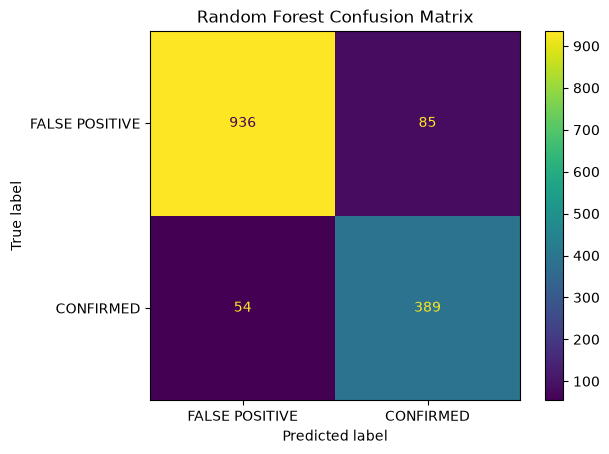

In [15]:
fig,ax=plt.subplots()

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    rf_pred,
    display_labels=["FALSE POSITIVE","CONFIRMED"],
    ax=ax
)

ax.set_title("Random Forest Confusion Matrix")
plt.show()

<Figure size 640x480 with 0 Axes>

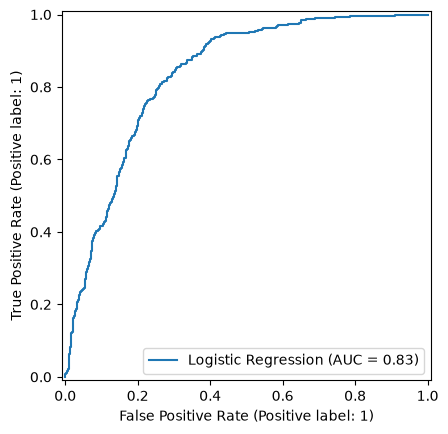

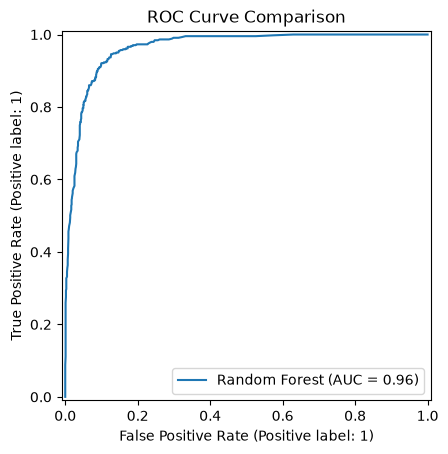

In [16]:
plt.figure()

RocCurveDisplay.from_predictions(
    test_labels,
    logistic_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    test_labels,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

In [17]:
feature_importance=pd.DataFrame({
    "Feature":usable_features,
    "Importance":rf_model.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

         Feature  Importance
2       koi_prad    0.244362
5  koi_model_snr    0.185942
0     koi_period    0.118121
1   koi_duration    0.097709
4      koi_insol    0.085501
3        koi_teq    0.083566
6      koi_steff    0.056273
8       koi_srad    0.050613
7      koi_slogg    0.046676
9     koi_kepmag    0.031237


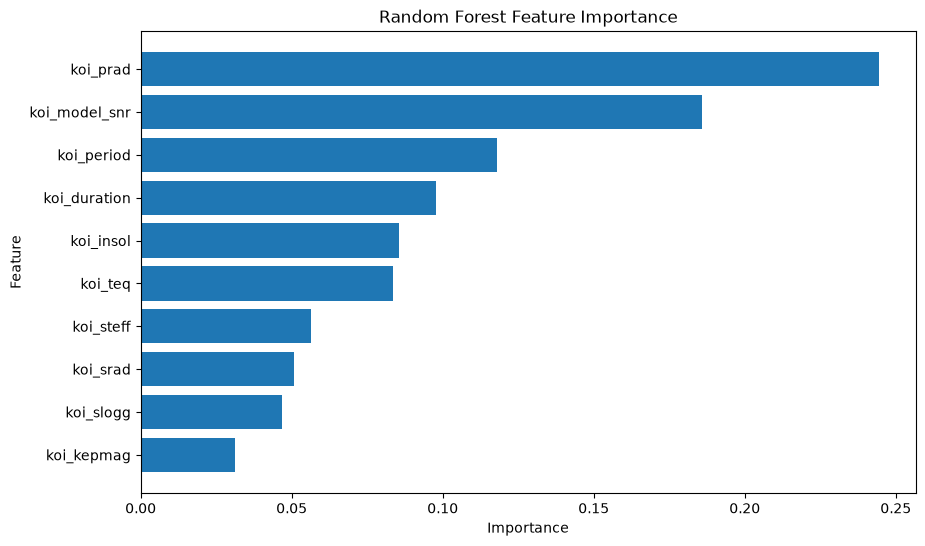

In [18]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [19]:
candidate_prob=rf_model.predict_proba(candidates_features)[:,1]
candidate_results=candidate_data.copy()
candidate_results["predicted_confirmed_probability"]=candidate_prob

print(candidate_results[
    ["kepid","kepoi_name","predicted_confirmed_probability"]
].head(10)
)

       kepid kepoi_name  predicted_confirmed_probability
10  11818800  K00777.01                         0.566667
13   3115833  K00797.01                         0.510000
18   4544670  K00815.01                         0.593333
37  11869052  K00120.01                         0.903333
40   7135852  K00875.01                         0.903333
41   7380537  K00883.01                         0.516667
43   8013419  K00901.01                         0.803333
49   8552202  K00914.01                         0.710000
57   9904059  K00145.01                         0.040000
58  10460629  K01168.01                         0.256667


In [20]:
candidate_results=candidate_results.sort_values(
    by="predicted_confirmed_probability",
    ascending=False
).reset_index(drop=True)
candidate_results["priority"]=pd.cut(
    candidate_results["predicted_confirmed_probability"],
    bins=[-np.inf,0.50,0.80,np.inf],
    labels=["Low","Medium","High"]
)
print(
    candidate_results[
    ["kepid","kepoi_name",
     "predicted_confirmed_probability","priority"]
    ].head(20)
)

       kepid kepoi_name  predicted_confirmed_probability priority
0    8804283  K01276.01                         0.990000     High
1    4274548  K01331.01                         0.973333     High
2    6291837  K00308.01                         0.973333     High
3    3937519  K00221.02                         0.963333     High
4    2832589  K01942.01                         0.956667     High
5    8709688  K03019.01                         0.950000     High
6    8578780  K02023.01                         0.950000     High
7    9823487  K01489.01                         0.950000     High
8    4770365  K01475.02                         0.946667     High
9    7386827  K01704.01                         0.943333     High
10   9244756  K01969.01                         0.940000     High
11   7700622  K00315.01                         0.940000     High
12  11570749  K01856.01                         0.940000     High
13  11718144  K02310.01                         0.940000     High
14   95809

In [21]:
candidate_results.to_csv(
    "memeber2_candidate_predictions.csv",
    index=False
)

model_comparison.to_csv(
    "member2_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "member2_feature_importance.csv",
    index=False
)

print("All member 2 results saved successfully")

All member 2 results saved successfully
